In [1]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==========================================
# 1. ฟังก์ชันโหลดไฟล์จาก GitHub
# ==========================================
def load_csvs_from_github(owner, repo, path, ref="main", token=None):
    session = requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
        
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    print(f"กำลังเชื่อมต่อ GitHub: {api_url}")
    
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    
    # สนใจเฉพาะไฟล์ 101-105
    target_files = ['101.csv', '102.csv', '103.csv', '104.csv', '105.csv']
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower() in target_files]
    
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        print(f"กำลังดาวน์โหลดและอ่านไฟล์: {it['name']} ...")
        try:
            # ใช้ skiprows=4 แบบโค้ดเซ็ตแรกของคุณ (คลีนและเสถียรกว่า)
            df = pd.read_csv(url, skiprows=4)
            df.columns = df.columns.str.strip()
            df['Frequency(Hz)'] = pd.to_numeric(df['Frequency(Hz)'], errors='coerce')
            
            # เก็บไฟล์ด้วย Key ที่เป็นตัวพิมพ์ใหญ่เพื่อความชัวร์ ('101.CSV', '102.CSV', ...)
            dfs[it["name"].upper()] = df
        except Exception as e:
            print(f"❌ Failed to read {it['name']}: {e}")
            
    return dfs

# ==========================================
# 2. ดึงข้อมูล
# ==========================================
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
# สมมติว่าเป็นโฟลเดอร์ 02 ตามข้อมูลชุดใหม่ที่คุณเขียนมา
path = "FirstDataset/02" 

# โหลดข้อมูลมาไว้ในตัวแปร dataframes
dataframes = load_csvs_from_github(owner, repo, path, ref="main", token=GITHUB_TOKEN)
print(f"\n✅ ดึงไฟล์สำเร็จ {len(dataframes)} ไฟล์: {list(dataframes.keys())}\n")

# ==========================================
# 3. วาดกราฟ 1 กราฟ ต่อ 1 ความถี่ (รวมข้อมูลจากทุกไฟล์)
# ==========================================
# สร้าง List ความถี่จาก 20 Hz ถึง 500 Hz (เพิ่มทีละ 20 Hz)
frequencies = list(range(20, 520, 20)) 

target_files = ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']
file_labels = ['101', '102', '103', '104', '105']

# แกน X ใช้ตัวเลข 1, 2, 3, 4, 5 เพื่อให้คำนวณ Linear Regression ได้
x = np.arange(1, 6) 

# วนลูปวาดกราฟตามความถี่ (จะได้ 25 กราฟ)
for freq in frequencies:
    cs_vals = []
    
    # ดึงค่า Cs จากไฟล์ 101 ถึง 105 ที่ความถี่เดียวกัน
    for f_name in target_files:
        if f_name in dataframes:
            df = dataframes[f_name]
            # ใช้ np.isclose เผื่อค่าทศนิยมในไฟล์คลาดเคลื่อนเล็กน้อย
            row = df[np.isclose(df['Frequency(Hz)'], freq)]
            if not row.empty:
                cs_vals.append(row['Cs(F)-data'].values[0])
            else:
                cs_vals.append(np.nan)
        else:
            cs_vals.append(np.nan)
            
    y = np.array(cs_vals)
    valid_idx = ~np.isnan(y) # เช็คว่าจุดไหนไม่มีค่า (NaN)
    
    # วาดกราฟ
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'bo-', label='Cs(F)-data', markersize=8)
    
    # หาค่าเทรนด์ (Linear Regression)
    if np.sum(valid_idx) > 1:
        slope, intercept, r_value, _, _ = linregress(x[valid_idx], y[valid_idx])
        plt.plot(x, slope * x + intercept, 'r--', label=f'Linear fit (R²={r_value**2:.4f})')
        title_text = f'Capacitance (Cs) Trend across files at {int(freq)} Hz\nEquation: y = {slope:.2e}x + {intercept:.2e}'
    else:
        title_text = f'Capacitance (Cs) Trend across files at {int(freq)} Hz'
        
    # ใส่ตัวเลขค่า Cs กํากับบนจุดแต่ละจุด
    for i, val in enumerate(y):
        if not np.isnan(val):
            plt.annotate(f'{val:.2e}', 
                         (x[i], val),
                         textcoords="offset points", 
                         xytext=(0, 15), 
                         ha='center', fontsize=10)

    # จัดการ Label 
    plt.title(title_text, fontsize=14)
    plt.xticks(x, file_labels, fontsize=12) # เปลี่ยนเลขแกน X ให้เป็นชื่อไฟล์ '101' ถึง '105'
    plt.xlabel('File Number (101 to 105)', fontsize=12)
    plt.ylabel('Cs(F)-data', fontsize=12)
    
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    
    # เซฟเป็นไฟล์รูปภาพอัตโนมัติ (ได้ 25 ไฟล์)
    filename = f'trend_at_{int(freq)}Hz.png'
    plt.savefig(filename)
    print(f"✅ บันทึกกราฟ {filename} เรียบร้อยแล้ว")
    
    # เคลียร์ Memory ไม่ให้กินแรมเครื่องเยอะตอนวาดครบ 25 กราฟ
    plt.close()

print("\n🎉 พล็อตกราฟครบทั้งหมด 25 ช่วงความถี่เรียบร้อยแล้ว!")

กำลังเชื่อมต่อ GitHub: https://api.github.com/repos/NuchPunnawichP/Senior_Project_CU/contents/FirstDataset/02?ref=main
กำลังดาวน์โหลดและอ่านไฟล์: 101.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 102.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 103.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 104.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 105.CSV ...

✅ ดึงไฟล์สำเร็จ 5 ไฟล์: ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']

✅ บันทึกกราฟ trend_at_20Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_40Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_60Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_80Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_100Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_120Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_140Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_160Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_180Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_200Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_220Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_240Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_260Hz.png เรียบร้อยแล้ว
✅ บันทึกกร

In [2]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==========================================
# 1. ฟังก์ชันโหลดไฟล์จาก GitHub
# ==========================================
def load_csvs_from_github(owner, repo, path, ref="main", token=None):
    session = requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
        
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    print(f"กำลังเชื่อมต่อ GitHub: {api_url}")
    
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    
    # สนใจเฉพาะไฟล์ 101-105
    target_files = ['101.csv', '102.csv', '103.csv', '104.csv', '105.csv']
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower() in target_files]
    
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        print(f"กำลังดาวน์โหลดและอ่านไฟล์: {it['name']} ...")
        try:
            # ใช้ skiprows=4 เพื่อข้าม Header บรรทัดบน
            df = pd.read_csv(url, skiprows=4)
            df.columns = df.columns.str.strip()
            df['Frequency(Hz)'] = pd.to_numeric(df['Frequency(Hz)'], errors='coerce')
            
            # เก็บไฟล์ด้วย Key ที่เป็นตัวพิมพ์ใหญ่เพื่อความชัวร์ ('101.CSV', '102.CSV', ...)
            dfs[it["name"].upper()] = df
        except Exception as e:
            print(f"❌ Failed to read {it['name']}: {e}")
            
    return dfs

# ==========================================
# 2. ดึงข้อมูล
# ==========================================
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
path = "FirstDataset/02" 

# โหลดข้อมูลมาไว้ในตัวแปร dataframes
dataframes = load_csvs_from_github(owner, repo, path, ref="main", token=GITHUB_TOKEN)
print(f"\n✅ ดึงไฟล์สำเร็จ {len(dataframes)} ไฟล์: {list(dataframes.keys())}\n")

# ==========================================
# 3. กำหนดโฟลเดอร์สำหรับเซฟรูปกราฟ (แก้ไขได้)
# ==========================================
# หากหาไฟล์ไม่เจอ ให้แก้บรรทัดนี้เป็น Path โฟลเดอร์หน้า Desktop ของคุณ
# ตัวอย่าง: SAVE_FOLDER = r"C:\Users\ชื่อคอมของคุณ\Desktop"
SAVE_FOLDER = "" 

# ==========================================
# 4. วาดกราฟ 1 กราฟ ต่อ 1 ความถี่ (รวมข้อมูลจากทุกไฟล์)
# ==========================================
# สร้าง List ความถี่จาก 20 Hz ถึง 500 Hz (เพิ่มทีละ 20 Hz)
frequencies = list(range(20, 520, 20)) 

target_files = ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']
file_labels = ['101', '102', '103', '104', '105']

# แกน X ใช้ตัวเลข 1, 2, 3, 4, 5 เพื่อให้คำนวณ Linear Regression ได้
x = np.arange(1, 6) 

# วนลูปวาดกราฟตามความถี่ (จะได้ 25 กราฟ)
for freq in frequencies:
    cs_vals = []
    
    # ดึงค่า Cs จากไฟล์ 101 ถึง 105 ที่ความถี่เดียวกัน
    for f_name in target_files:
        if f_name in dataframes:
            df = dataframes[f_name]
            # ใช้ np.isclose เผื่อค่าทศนิยมคลาดเคลื่อน
            row = df[np.isclose(df['Frequency(Hz)'], freq)]
            if not row.empty:
                cs_vals.append(row['Cs(F)-data'].values[0])
            else:
                cs_vals.append(np.nan)
        else:
            cs_vals.append(np.nan)
            
    y = np.array(cs_vals)
    valid_idx = ~np.isnan(y) # เช็คว่าจุดไหนไม่มีค่า (NaN)
    
    # วาดกราฟ
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'bo-', label='Cs(F)-data', markersize=8)
    
    # หาค่าเทรนด์ (Linear Regression)
    if np.sum(valid_idx) > 1:
        slope, intercept, r_value, _, _ = linregress(x[valid_idx], y[valid_idx])
        plt.plot(x, slope * x + intercept, 'r--', label=f'Linear fit (R²={r_value**2:.4f})')
        title_text = f'Capacitance (Cs) Trend across files at {int(freq)} Hz\nEquation: y = {slope:.2e}x + {intercept:.2e}'
    else:
        title_text = f'Capacitance (Cs) Trend across files at {int(freq)} Hz'
        
    # ใส่ตัวเลขค่า Cs กํากับบนจุดแต่ละจุด
    for i, val in enumerate(y):
        if not np.isnan(val):
            plt.annotate(f'{val:.2e}', 
                         (x[i], val),
                         textcoords="offset points", 
                         xytext=(0, 15), 
                         ha='center', fontsize=10)

    # จัดการ Label 
    plt.title(title_text, fontsize=14)
    plt.xticks(x, file_labels, fontsize=12) # เปลี่ยนเลขแกน X ให้เป็นชื่อไฟล์ '101' ถึง '105'
    plt.xlabel('File Number (101 to 105)', fontsize=12)
    plt.ylabel('Cs(F)-data', fontsize=12)
    
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    
    # จัดการชื่อไฟล์และโฟลเดอร์สำหรับเซฟ
    filename = f'trend_at_{int(freq)}Hz.png'
    if SAVE_FOLDER:
        filename = os.path.join(SAVE_FOLDER, filename)
        
    plt.savefig(filename)
    print(f"✅ บันทึกกราฟ {filename} เรียบร้อยแล้ว")
    
    # เคลียร์ Memory ไม่ให้กินแรมเครื่องเยอะ
    plt.close()

print("\n🎉 พล็อตกราฟครบทั้งหมด 25 ช่วงความถี่เรียบร้อยแล้ว!")

กำลังเชื่อมต่อ GitHub: https://api.github.com/repos/NuchPunnawichP/Senior_Project_CU/contents/FirstDataset/02?ref=main
กำลังดาวน์โหลดและอ่านไฟล์: 101.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 102.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 103.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 104.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 105.CSV ...

✅ ดึงไฟล์สำเร็จ 5 ไฟล์: ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']

✅ บันทึกกราฟ trend_at_20Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_40Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_60Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_80Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_100Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_120Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_140Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_160Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_180Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_200Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_220Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_240Hz.png เรียบร้อยแล้ว
✅ บันทึกกราฟ trend_at_260Hz.png เรียบร้อยแล้ว
✅ บันทึกกร

กำลังเชื่อมต่อ GitHub: https://api.github.com/repos/NuchPunnawichP/Senior_Project_CU/contents/FirstDataset/02?ref=main
กำลังดาวน์โหลดและอ่านไฟล์: 101.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 102.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 103.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 104.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 105.CSV ...

✅ ดึงไฟล์สำเร็จ 5 ไฟล์: ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']

📊 กำลังแสดงกราฟที่ความถี่ 20 Hz ... (กรุณากดกากบาทปิดหน้าต่างกราฟเพื่อดูรูปถัดไป)


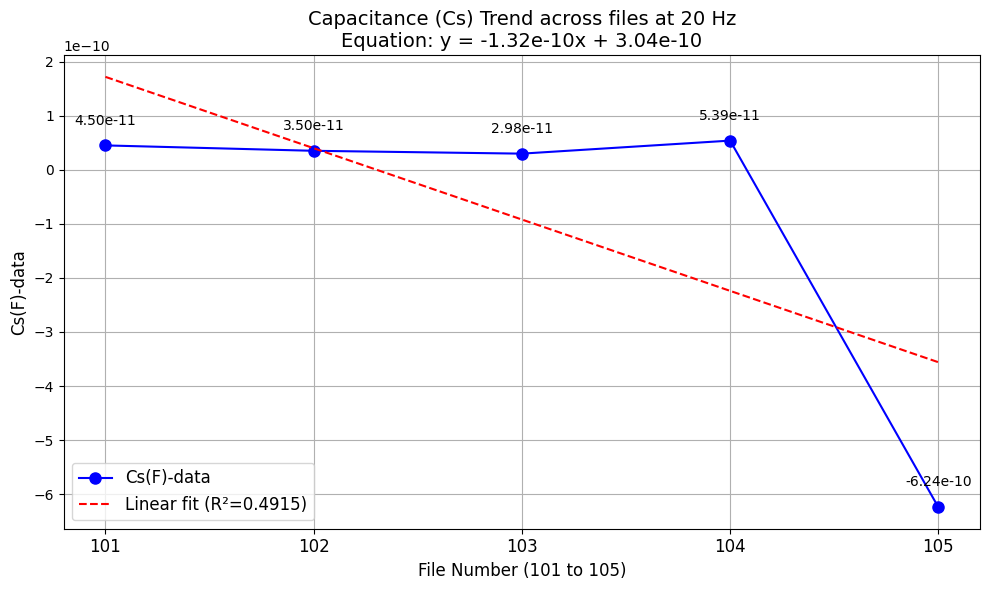

📊 กำลังแสดงกราฟที่ความถี่ 40 Hz ... (กรุณากดกากบาทปิดหน้าต่างกราฟเพื่อดูรูปถัดไป)


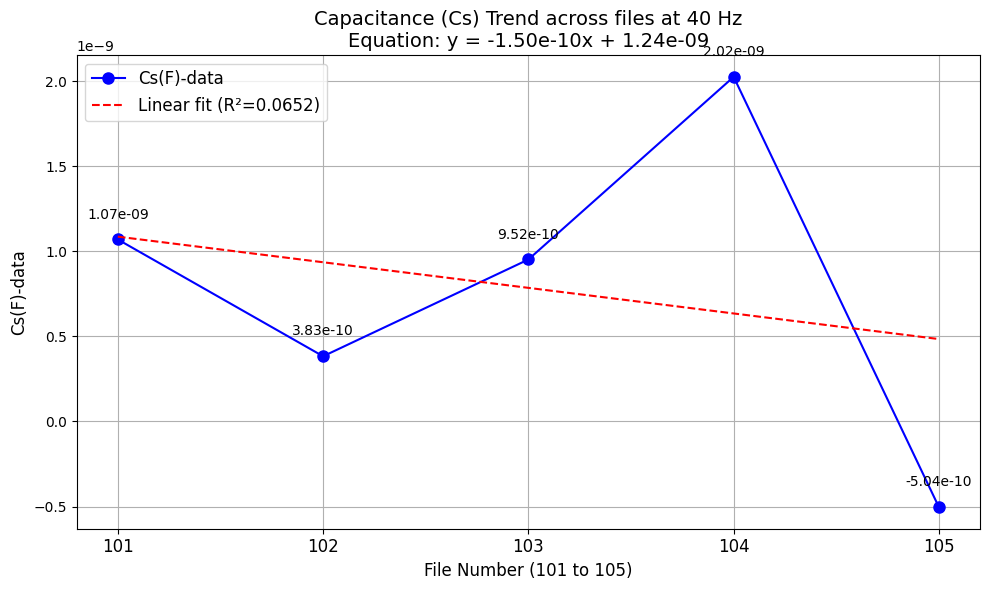

📊 กำลังแสดงกราฟที่ความถี่ 60 Hz ... (กรุณากดกากบาทปิดหน้าต่างกราฟเพื่อดูรูปถัดไป)


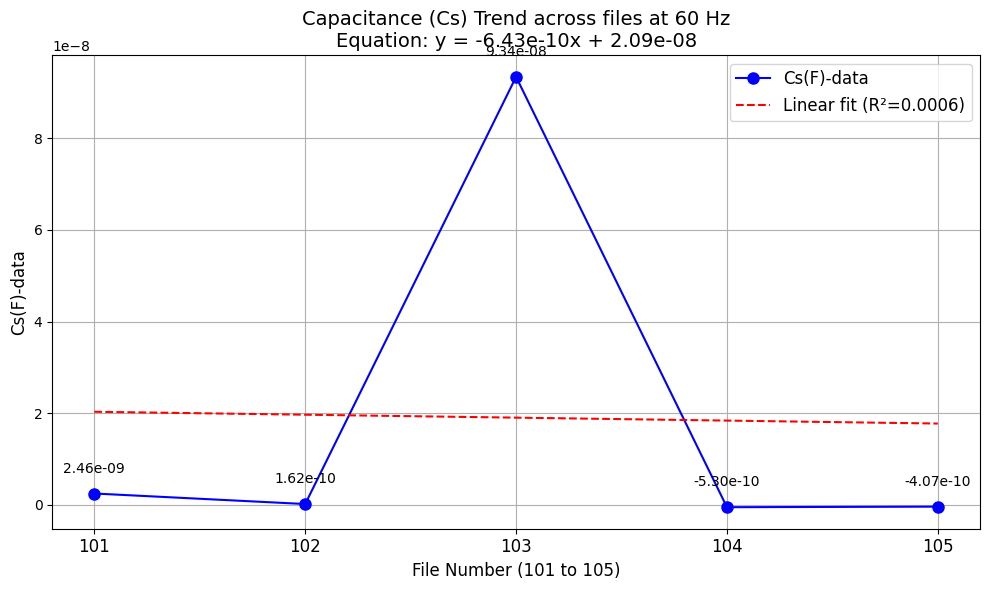

📊 กำลังแสดงกราฟที่ความถี่ 80 Hz ... (กรุณากดกากบาทปิดหน้าต่างกราฟเพื่อดูรูปถัดไป)


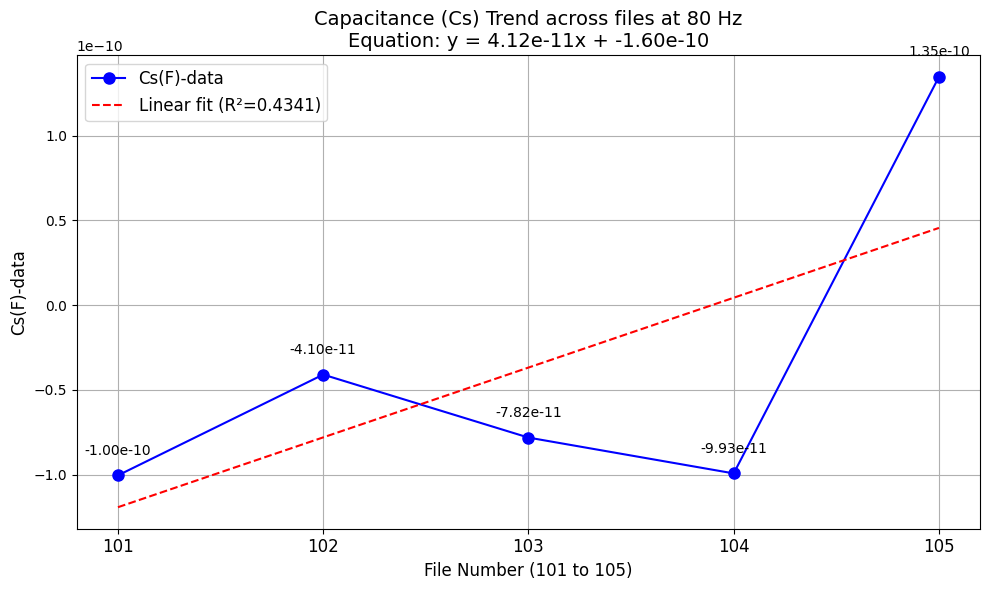

📊 กำลังแสดงกราฟที่ความถี่ 100 Hz ... (กรุณากดกากบาทปิดหน้าต่างกราฟเพื่อดูรูปถัดไป)


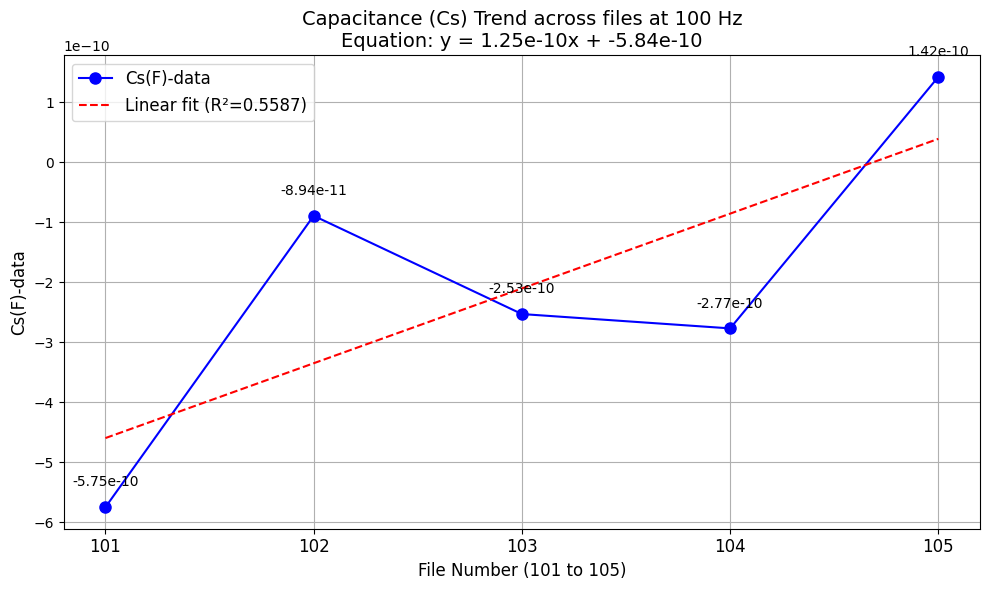


🎉 พล็อตกราฟครบทั้งหมดเรียบร้อยแล้ว!


In [3]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==========================================
# 1. ฟังก์ชันโหลดไฟล์จาก GitHub
# ==========================================
def load_csvs_from_github(owner, repo, path, ref="main", token=None):
    session = requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
        
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    print(f"กำลังเชื่อมต่อ GitHub: {api_url}")
    
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    
    # สนใจเฉพาะไฟล์ 101-105
    target_files = ['101.csv', '102.csv', '103.csv', '104.csv', '105.csv']
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower() in target_files]
    
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        print(f"กำลังดาวน์โหลดและอ่านไฟล์: {it['name']} ...")
        try:
            # ใช้ skiprows=4 เพื่อข้าม Header บรรทัดบน
            df = pd.read_csv(url, skiprows=4)
            df.columns = df.columns.str.strip()
            df['Frequency(Hz)'] = pd.to_numeric(df['Frequency(Hz)'], errors='coerce')
            
            # เก็บไฟล์ด้วย Key ที่เป็นตัวพิมพ์ใหญ่เพื่อความชัวร์ ('101.CSV', '102.CSV', ...)
            dfs[it["name"].upper()] = df
        except Exception as e:
            print(f"❌ Failed to read {it['name']}: {e}")
            
    return dfs

# ==========================================
# 2. ดึงข้อมูล
# ==========================================
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
path = "FirstDataset/02"  # เปลี่ยนโฟลเดอร์ตามที่คุณต้องการ

# โหลดข้อมูลมาไว้ในตัวแปร dataframes
dataframes = load_csvs_from_github(owner, repo, path, ref="main", token=GITHUB_TOKEN)
print(f"\n✅ ดึงไฟล์สำเร็จ {len(dataframes)} ไฟล์: {list(dataframes.keys())}\n")

# ==========================================
# 3. วาดกราฟและแสดงผล 1 กราฟ ต่อ 1 ความถี่ 
# ==========================================
# สร้าง List ความถี่จาก 20 Hz ถึง 500 Hz (เพิ่มทีละ 20 Hz)
frequencies = list(range(20, 520, 20)) 

target_files = ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']
file_labels = ['101', '102', '103', '104', '105']

# แกน X ใช้ตัวเลข 1, 2, 3, 4, 5 เพื่อให้คำนวณ Linear Regression ได้
x = np.arange(1, 6) 

# วนลูปวาดกราฟตามความถี่ (จะได้ 25 กราฟ)
for freq in frequencies:
    cs_vals = []
    
    # ดึงค่า Cs จากไฟล์ 101 ถึง 105 ที่ความถี่เดียวกัน
    for f_name in target_files:
        if f_name in dataframes:
            df = dataframes[f_name]
            # ใช้ np.isclose เผื่อค่าทศนิยมคลาดเคลื่อน
            row = df[np.isclose(df['Frequency(Hz)'], freq)]
            if not row.empty:
                cs_vals.append(row['Cs(F)-data'].values[0])
            else:
                cs_vals.append(np.nan)
        else:
            cs_vals.append(np.nan)
            
    y = np.array(cs_vals)
    valid_idx = ~np.isnan(y) # เช็คว่าจุดไหนไม่มีค่า (NaN)
    
    # ถ้าไม่มีข้อมูลในย่านความถี่นี้เลย ให้ข้ามไป จะได้ไม่ Error
    if np.sum(valid_idx) == 0:
        continue
    
    # วาดกราฟ
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'bo-', label='Cs(F)-data', markersize=8)
    
    # หาค่าเทรนด์ (Linear Regression)
    if np.sum(valid_idx) > 1:
        slope, intercept, r_value, _, _ = linregress(x[valid_idx], y[valid_idx])
        plt.plot(x, slope * x + intercept, 'r--', label=f'Linear fit (R²={r_value**2:.4f})')
        title_text = f'Capacitance (Cs) Trend across files at {int(freq)} Hz\nEquation: y = {slope:.2e}x + {intercept:.2e}'
    else:
        title_text = f'Capacitance (Cs) Trend across files at {int(freq)} Hz'
        
    # ใส่ตัวเลขค่า Cs กํากับบนจุดแต่ละจุด
    for i, val in enumerate(y):
        if not np.isnan(val):
            plt.annotate(f'{val:.2e}', 
                         (x[i], val),
                         textcoords="offset points", 
                         xytext=(0, 15), 
                         ha='center', fontsize=10)

    # จัดการ Label 
    plt.title(title_text, fontsize=14)
    plt.xticks(x, file_labels, fontsize=12) # เปลี่ยนเลขแกน X ให้เป็นชื่อไฟล์ '101' ถึง '105'
    plt.xlabel('File Number (101 to 105)', fontsize=12)
    plt.ylabel('Cs(F)-data', fontsize=12)
    
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    
    # 🌟 คำสั่งนี้จะทำให้หน้าต่างกราฟเด้งขึ้นมากลางจอ 🌟
    print(f"📊 กำลังแสดงกราฟที่ความถี่ {int(freq)} Hz ... (กรุณากดกากบาทปิดหน้าต่างกราฟเพื่อดูรูปถัดไป)")
    plt.show()

print("\n🎉 พล็อตกราฟครบทั้งหมดเรียบร้อยแล้ว!")